 # Artificial Intelligence Technology and Application

 ## Deep Learning Lab Guide - Student Version

 # 1 MobileNetV2 Image Classification

 ## 1.1 Introduction

 In this exercise, the lightweight network MobileNetV2 is used to classify flower image datasets.

 ## 1.3 Detailed Design and Implementation

 ### 1.3.1 Data Preparation

 Five flower types: daisies, dandelions, roses, sunflowers, and tulips.

 Ensure the dataset is stored in `flower_photos_train` and `flower_photos_test`.

 ### 1.3.2 Procedure

 **Step 1: Load the dataset.**

In [1]:
import os

try:
    import mindspore as ms
    import mindspore.dataset as ds
    import mindspore.dataset.vision as CV
    from mindspore import dtype as mstype

    train_data_path = 'flower_photos_train'
    val_data_path = 'flower_photos_test'

    if not os.path.exists(train_data_path) or not os.path.exists(val_data_path):
        import kagglehub
        import shutil
        import random
        print("Downloading flower dataset using kagglehub...")
        path = kagglehub.dataset_download("alxmamaev/flowers-recognition")
        
        flowers_dir = None
        for root, dirs, files in os.walk(path):
            if 'daisy' in dirs and 'sunflower' in dirs:
                flowers_dir = root
                break
                
        if flowers_dir:
            os.makedirs(train_data_path, exist_ok=True)
            os.makedirs(val_data_path, exist_ok=True)
            class_map = {'daisy': 'daisy', 'dandelion': 'dandelion', 'rose': 'roses', 'sunflower': 'sunflowers', 'tulip': 'tulips'}
            
            for k_cls, dest_cls in class_map.items():
                os.makedirs(os.path.join(train_data_path, dest_cls), exist_ok=True)
                os.makedirs(os.path.join(val_data_path, dest_cls), exist_ok=True)
                
                cls_dir = os.path.join(flowers_dir, k_cls)
                images = [f for f in os.listdir(cls_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
                random.shuffle(images)
                
                split_idx = int(len(images) * 0.8)
                for img in images[:split_idx]:
                    shutil.copy(os.path.join(cls_dir, img), os.path.join(train_data_path, dest_cls, img))
                for img in images[split_idx:]:
                    shutil.copy(os.path.join(cls_dir, img), os.path.join(val_data_path, dest_cls, img))
            print("Flower dataset beautifully downloaded and processed into training/validation sets!")

    def create_dataset(data_path, batch_size=18, training=True):
        if not os.path.exists(data_path):
            return None

        data_set = ds.ImageFolderDataset(data_path, num_parallel_workers=4, shuffle=True,
                                         class_indexing={'daisy': 0, 'dandelion': 1, 'roses': 2,
                                                         'sunflowers': 3, 'tulips': 4})
        image_size = 224
        mean = [0.485 * 255, 0.456 * 255, 0.406 * 255]
        std = [0.229 * 255, 0.224 * 255, 0.225 * 255]

        if training:
            trans = [
                CV.RandomCropDecodeResize(image_size, scale=(0.08, 1.0), ratio=(0.75, 1.333)),
                CV.RandomHorizontalFlip(prob=0.5),
                CV.Normalize(mean=mean, std=std),
                CV.HWC2CHW()
            ]
        else:
            trans = [
                CV.Decode(),
                CV.Resize(256),
                CV.CenterCrop(image_size),
                CV.Normalize(mean=mean, std=std),
                CV.HWC2CHW()
            ]

        data_set = data_set.map(operations=trans, input_columns="image", num_parallel_workers=4)
        data_set = data_set.batch(batch_size, drop_remainder=True)
        return data_set

    dataset_train = create_dataset(train_data_path)
    dataset_val = create_dataset(val_data_path)
    print("Dataset processed successfully.")
except ImportError:
    print("MindSpore is not installed.")


Dataset processed successfully.


 **Step 2: Visualize the dataset.**

Tensor of image: (18, 3, 224, 224)
Labels: [3 0 2 1 2 2 4 3 4 3 1 2 3 1 4 2 4 3]


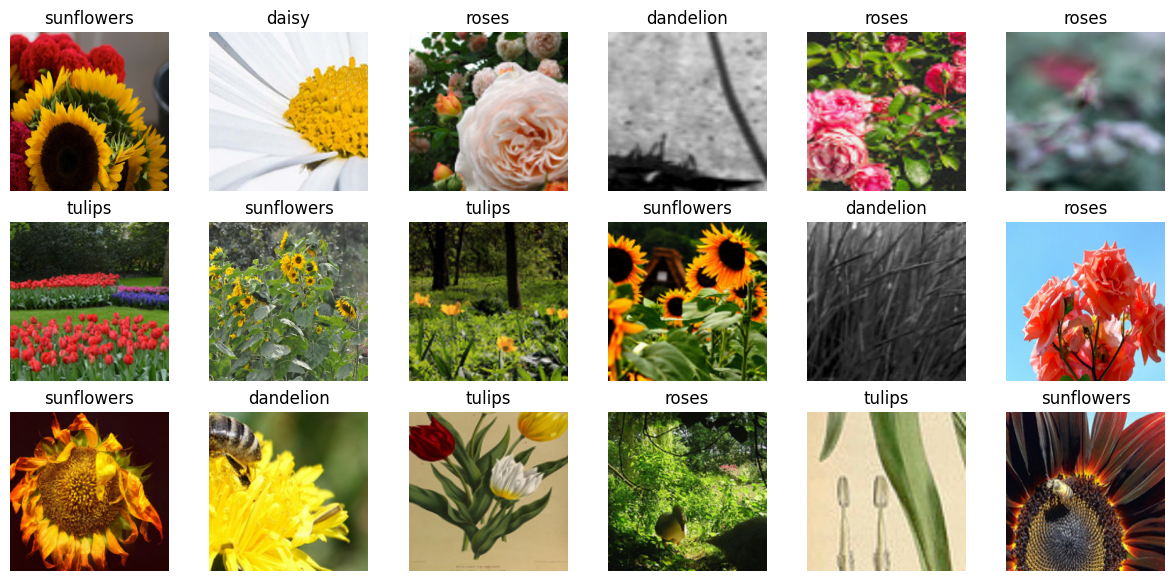

In [2]:
try:
    import matplotlib.pyplot as plt
    import numpy as np

    if dataset_train:
        data = next(dataset_train.create_dict_iterator())
        images = data["image"].asnumpy()
        labels = data["label"].asnumpy()

        print("Tensor of image:", images.shape)
        print("Labels:", labels)

        class_name = {0: 'daisy', 1: 'dandelion', 2: 'roses', 3: 'sunflowers', 4: 'tulips'}
        
        plt.figure(figsize=(15, 7))
        for i in range(min(18, len(labels))):
            data_image = images[i]
            data_image = np.transpose(data_image, (1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            data_image = std * data_image + mean
            data_image = np.clip(data_image, 0, 1)
            
            plt.subplot(3, 6, i + 1)
            plt.imshow(data_image)
            plt.title(class_name[int(labels[i])])
            plt.axis("off")
        plt.show()
except NameError:
    pass


 **Step 3: Create a MobileNetV2 model.**

In [3]:
try:
    import mindspore.nn as nn
    import mindspore.ops as ops

    def _make_divisible(v, divisor, min_value=None):
        if min_value is None:
            min_value = divisor
        new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
        if new_v < 0.9 * v:
            new_v += divisor
        return new_v

    class GlobalAvgPooling(nn.Cell):
        def __init__(self):
            super(GlobalAvgPooling, self).__init__()
            self.mean = ops.ReduceMean(keep_dims=False)

        def construct(self, x):
            x = self.mean(x, (2, 3))
            return x

    class ConvBNReLU(nn.Cell):
        def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, groups=1):
            super(ConvBNReLU, self).__init__()
            padding = (kernel_size - 1) // 2
            in_channels = in_planes
            out_channels = out_planes
            if groups == 1:
                conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, pad_mode='pad', padding=padding)
            else:
                out_channels = in_planes
                conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, pad_mode='pad', padding=padding, group=in_channels)
            
            layers = [conv, nn.BatchNorm2d(out_planes), nn.ReLU6()]
            self.features = nn.SequentialCell(layers)

        def construct(self, x):
            return self.features(x)

    class InvertedResidual(nn.Cell):
        def __init__(self, inp, oup, stride, expand_ratio):
            super(InvertedResidual, self).__init__()
            self.use_res_connect = stride == 1 and inp == oup
            hidden_dim = int(round(inp * expand_ratio))
            layers = []
            if expand_ratio != 1:
                layers.append(ConvBNReLU(inp, hidden_dim, kernel_size=1))
            layers.extend([
                ConvBNReLU(hidden_dim, hidden_dim, stride=stride, groups=hidden_dim),
                nn.Conv2d(hidden_dim, oup, kernel_size=1, stride=1, has_bias=False),
                nn.BatchNorm2d(oup),
            ])
            self.conv = nn.SequentialCell(layers)
            self.add = ops.Add()

        def construct(self, x):
            if self.use_res_connect:
                return self.add(x, self.conv(x))
            return self.conv(x)

    class MobileNetV2Backbone(nn.Cell):
        def __init__(self, width_mult=1., round_nearest=8):
            super(MobileNetV2Backbone, self).__init__()
            block = InvertedResidual
            input_channel = 32
            last_channel = 1280
            inverted_residual_setting = [
                [1, 16, 1, 1], [6, 24, 2, 2], [6, 32, 3, 2],
                [6, 64, 4, 2], [6, 96, 3, 1], [6, 160, 3, 2],
                [6, 320, 1, 1],
            ]
            self.cfgs = inverted_residual_setting
            input_channel = _make_divisible(input_channel * width_mult, round_nearest)
            self.out_channels = _make_divisible(last_channel * max(1.0, width_mult), round_nearest)
            
            features = [ConvBNReLU(3, input_channel, stride=2)]
            for t, c, n, s in self.cfgs:
                output_channel = _make_divisible(c * width_mult, round_nearest)
                for i in range(n):
                    stride = s if i == 0 else 1
                    features.append(block(input_channel, output_channel, stride, expand_ratio=t))
                    input_channel = output_channel
            
            features.append(ConvBNReLU(input_channel, self.out_channels, kernel_size=1))
            self.features = nn.SequentialCell(features)

        def construct(self, x):
            return self.features(x)

    class MobileNetV2Head(nn.Cell):
        def __init__(self, input_channel=1280, num_classes=1000):
            super(MobileNetV2Head, self).__init__()
            self.head = nn.SequentialCell([GlobalAvgPooling(), nn.Dropout(keep_prob=0.8)])
            self.dense = nn.Dense(input_channel, num_classes, has_bias=True)

        def construct(self, x):
            x = self.head(x)
            return self.dense(x)

    class MobileNetV2Combine(nn.Cell):
        def __init__(self, backbone, head):
            super(MobileNetV2Combine, self).__init__(auto_prefix=False)
            self.backbone = backbone
            self.head = head

        def construct(self, x):
            x = self.backbone(x)
            return self.head(x)

    def mobilenet_v2(num_classes):
        backbone_net = MobileNetV2Backbone()
        head_net = MobileNetV2Head(backbone_net.out_channels, num_classes)
        return MobileNetV2Combine(backbone_net, head_net)

    print("MobileNetV2 architecture defined.")
except NameError:
    pass


MobileNetV2 architecture defined.


 **Step 4: Train and validate the model.**

In [4]:
try:
    from mindspore.train import Model
    from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor
    from mindspore.train.serialization import load_checkpoint, load_param_into_net

    network = mobilenet_v2(5)
    
    ckpt_path = "./mobilenetv2_ascend_v170_imagenet2012_official_cv_top1acc71.88.ckpt"
    if not os.path.exists(ckpt_path):
        import urllib.request
        print(f"Downloading pre-trained weights {ckpt_path} from MindSpore...")
        urllib.request.urlretrieve("https://download.mindspore.cn/models/r1.7/mobilenetv2_ascend_v170_imagenet2012_official_cv_top1acc71.88.ckpt", ckpt_path)
        print("Download complete!")

    if os.path.exists(ckpt_path):
        param_dict = load_checkpoint(ckpt_path)
        param_dict["dense.weight"] = ms.Parameter(ms.Tensor(param_dict["dense.weight"][:5, :], ms.float32), name="dense.weight")
        param_dict["dense.bias"] = ms.Parameter(ms.Tensor(param_dict["dense.bias"][:5], ms.float32), name="dense.bias")
        load_param_into_net(network, param_dict)
        print("Pre-trained weight loaded successfully.")

    if dataset_train:
        train_step_size = dataset_train.get_dataset_size()
        epoch_size = 5
        lr = nn.cosine_decay_lr(min_lr=0.0, max_lr=0.1, total_step=epoch_size * train_step_size, step_per_epoch=train_step_size, decay_epoch=5)
        
        network_opt = nn.Momentum(params=network.trainable_params(), learning_rate=0.01, momentum=0.9)
        loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')
        
        model = Model(network, loss_fn, network_opt, metrics={'Accuracy': nn.metrics.Accuracy()})
        
        loss_cb = LossMonitor(per_print_times=train_step_size)
        
        print("Starting Training...")
        model.train(epoch_size, dataset_train, callbacks=[loss_cb], dataset_sink_mode=False)

        metric = model.eval(dataset_val, dataset_sink_mode=False)
        print("Validation Result:", metric)
except NameError:
    pass


[WARNING] ME(6692:140117980373120,MainProcess):2026-04-03-02:44:32.775.000 [mindspore/nn/layer/basic.py:178] For Dropout, this parameter `keep_prob` will be deprecated, please use `p` instead.


Pre-trained weight loaded successfully.
Starting Training...
epoch: 1 step: 191, loss is 0.811830461025238
epoch: 2 step: 191, loss is 0.28555452823638916
epoch: 3 step: 191, loss is 0.6641271114349365
epoch: 4 step: 191, loss is 0.20235008001327515
epoch: 5 step: 191, loss is 0.3976227343082428
Validation Result: {'Accuracy': 0.8599537037037037}


 **Step 5: Visualize the model prediction result.**

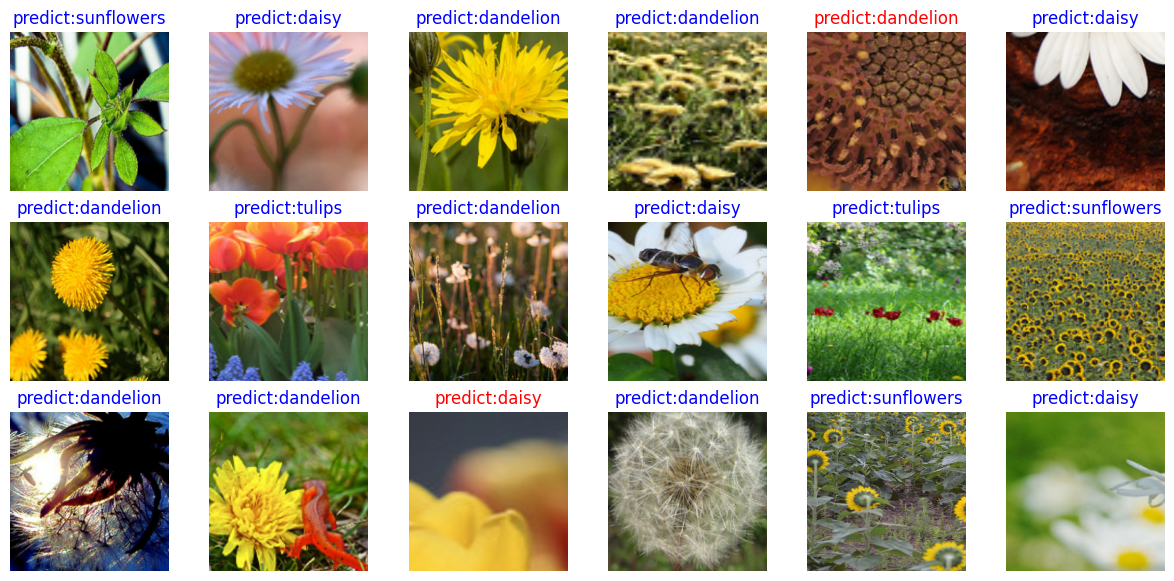

In [5]:
try:
    def visualize_model(val_ds):
        if not val_ds:
            return
        data = next(val_ds.create_dict_iterator())
        images = data["image"].asnumpy()
        labels = data["label"].asnumpy()
        class_name = {0: 'daisy', 1: 'dandelion', 2: 'roses', 3: 'sunflowers', 4: 'tulips'}
        
        output = model.predict(ms.Tensor(data['image']))
        pred = np.argmax(output.asnumpy(), axis=1)

        plt.figure(figsize=(15, 7))
        for i in range(min(18, len(labels))):
            plt.subplot(3, 6, i + 1)
            color = 'blue' if pred[i] == labels[i] else 'red'
            plt.title('predict:{}'.format(class_name[pred[i]]), color=color)
            
            picture_show = np.transpose(images[i], (1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            picture_show = std * picture_show + mean
            picture_show = np.clip(picture_show, 0, 1)
            
            plt.imshow(picture_show)
            plt.axis('off')

        plt.show()

    visualize_model(dataset_val)
except NameError:
    pass
